# 📦 **1. Load Data Polis dan Klaim**

In [ ]:
#cloning data
!git clone https://github.com/herlian93/Database-DSC-HEYKA.git

Cloning into 'Database-DSC-HEYKA'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 11 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 605.94 KiB | 5.51 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

klaim = pd.read_csv(
    "/content/Database-DSC-HEYKA/Data Klaim Asuransi_HEYKA.csv",
    sep=';'
)
polis = pd.read_csv(
    "/content/Database-DSC-HEYKA/Data Polis Asuransi_HEYKA.csv",
    sep=';'
)

print('Data Polis:', polis.shape)
print('Data Klaim:', klaim.shape)
polis.head()

Data Polis: (4096, 6)
Data Klaim: (4627, 13)


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA


In [ ]:
klaim.head()

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


# 🔍 **2. Exploratory Data Analysis (EDA)**

## 2.1 Cek Tipe Data & Info

In [ ]:
polis.info()
klaim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient  

## 2.2 Persentase Missing Value

In [ ]:
print('=== Missing Value Polis ===')
print((polis.isnull().sum()/len(polis)*100).round(2))
print('\n=== Missing Value Klaim ===')
print((klaim.isnull().sum()/len(klaim)*100).round(2))

=== Missing Value Polis ===
Nomor Polis              0.0
Plan Code                0.0
Gender                   0.0
Tanggal Lahir            0.0
Tanggal Efektif Polis    0.0
Domisili                 0.0
dtype: float64

=== Missing Value Klaim ===
Claim ID                         0.00
Nomor Polis                      0.00
Reimburse/Cashless               0.00
Inpatient/Outpatient             0.80
ICD Diagnosis                    0.13
ICD Description                  0.13
Status Klaim                     0.00
Tanggal Pembayaran Klaim         0.80
Tanggal Pasien Masuk RS          0.00
Tanggal Pasien Keluar RS         0.00
Nominal Klaim Yang Disetujui     0.00
Nominal Biaya RS Yang Terjadi    0.00
Lokasi RS                        0.15
dtype: float64


## 2.3 Pembersihan & Imputasi Missing Value

In [ ]:
# Convert tanggal ke datetime
klaim['Tanggal Pembayaran Klaim'] = pd.to_datetime(klaim['Tanggal Pembayaran Klaim'], errors='coerce')
klaim['Tanggal Pasien Masuk RS']  = pd.to_datetime(klaim['Tanggal Pasien Masuk RS'],  errors='coerce')
klaim['Tanggal Pasien Keluar RS'] = pd.to_datetime(klaim['Tanggal Pasien Keluar RS'], errors='coerce')

# Isi missing value kategori minor
klaim['Inpatient/Outpatient'] = klaim['Inpatient/Outpatient'].fillna('Unknown')
klaim['ICD Diagnosis']        = klaim['ICD Diagnosis'].fillna('Unknown')
klaim['ICD Description']      = klaim['ICD Description'].fillna('Unknown')
klaim['Lokasi RS']            = klaim['Lokasi RS'].fillna('Unknown')

# Fitur: status pembayaran
klaim['Sudah Dibayar'] = klaim['Tanggal Pembayaran Klaim'].notnull().astype(int)

print('Data Klaim setelah pembersihan:')
klaim.info()

Data Klaim setelah pembersihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   object        
 1   Nomor Polis                    4627 non-null   object        
 2   Reimburse/Cashless             4627 non-null   object        
 3   Inpatient/Outpatient           4627 non-null   object        
 4   ICD Diagnosis                  4627 non-null   object        
 5   ICD Description                4627 non-null   object        
 6   Status Klaim                   4627 non-null   object        
 7   Tanggal Pembayaran Klaim       4590 non-null   datetime64[ns]
 8   Tanggal Pasien Masuk RS        4627 non-null   datetime64[ns]
 9   Tanggal Pasien Keluar RS       4627 non-null   datetime64[ns]
 10  Nominal Klaim Yang Disetujui   4627 non-null   float

## 2.4 Cek Duplikasi

In [ ]:
print('Duplikasi Polis:', polis.duplicated().sum())
print('Duplikasi Klaim:', klaim.duplicated().sum())

Duplikasi Polis: 0
Duplikasi Klaim: 0


## 2.5 Deteksi & Penanganan Outlier

In [ ]:
klaim.describe()

,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Sudah Dibayar
count,4590,4627,4627,4.627000e+03,4.627000e+03,4627.000000
mean,2024-12-16 04:44:51.764705792,2024-10-10 18:15:28.982061824,2024-10-12 00:35:47.395720704,5.502892e+07,5.994940e+07,0.992003
min,2024-01-17 00:00:00,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000e+00,0.000000e+00,0.000000
25%,2024-08-06 00:00:00,2024-05-16 12:00:00,2024-05-17 00:00:00,2.274009e+06,2.720210e+06,1.000000
50%,2024-12-06 00:00:00,2024-10-11 00:00:00,2024-10-13 00:00:00,1.446790e+07,1.587100e+07,1.000000
75%,2025-05-06 00:00:00,2025-03-03 00:00:00,2025-03-04 00:00:00,5.107209e+07,5.423067e+07,1.000000
max,2025-12-09 00:00:00,2025-07-31 00:00:00,2025-08-09 00:00:00,2.197500e+09,3.892810e+09,1.000000
std,NaN,NaN,NaN,1.319527e+08,1.597838e+08,0.089075


In [ ]:
Q1 = klaim['Nominal Klaim Yang Disetujui'].quantile(0.25)
Q3 = klaim['Nominal Klaim Yang Disetujui'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

klaim_outlier = klaim[(klaim['Nominal Klaim Yang Disetujui'] < lower_bound) |
                      (klaim['Nominal Klaim Yang Disetujui'] > upper_bound)]
print(f'Batas Bawah : {lower_bound:,.0f}')
print(f'Batas Atas  : {upper_bound:,.0f}')
print(f'Jumlah Outlier: {len(klaim_outlier)}')

klaim_bersih = klaim[(klaim['Nominal Klaim Yang Disetujui'] >= lower_bound) &
                     (klaim['Nominal Klaim Yang Disetujui'] <= upper_bound)]
print(f'Data asli   : {len(klaim)}')
print(f'Data bersih : {len(klaim_bersih)}')

Batas Bawah : -70,923,104
Batas Atas  : 124,269,199
Jumlah Outlier: 507
Data asli   : 4627
Data bersih : 4120


## 2.6 Normalisasi (Log Transformation)

In [ ]:
print('Skewness awal:', klaim['Nominal Klaim Yang Disetujui'].skew())

klaim = klaim[klaim['Nominal Klaim Yang Disetujui'] >= 0]
klaim['severity']     = klaim['Nominal Klaim Yang Disetujui']
klaim['severity_log'] = np.log1p(klaim['severity'])

# Terapkan juga ke klaim_bersih
klaim_bersih = klaim_bersih.copy()
klaim_bersih['severity']     = klaim_bersih['Nominal Klaim Yang Disetujui']
klaim_bersih['severity_log'] = np.log1p(klaim_bersih['severity'])

print('Skewness setelah log:', klaim['severity_log'].skew())
print(klaim[['severity','severity_log']].head())

Skewness awal: 6.639577239513242
Skewness setelah log: -1.18023776573267
      severity  severity_log
0   28093653.0     17.151054
1   80987278.0     18.209803
2  183047130.0     19.025254
3  191424386.0     19.070003
4  138936357.0     18.749527


# ⚙️ **3. Feature Engineering**

In [ ]:
# Merge Klaim + Polis
baru = klaim.merge(polis, on='Nomor Polis', how='left')

# 1. Rasio Persetujuan Klaim
baru['approval_ratio'] = baru['Nominal Klaim Yang Disetujui'] / (baru['Nominal Biaya RS Yang Terjadi'] + 1)

# 2. Lama Rawat (hari)
baru['Tanggal Pasien Masuk RS']  = pd.to_datetime(baru['Tanggal Pasien Masuk RS'])
baru['Tanggal Pasien Keluar RS'] = pd.to_datetime(baru['Tanggal Pasien Keluar RS'])
baru['lama_rawat'] = (baru['Tanggal Pasien Keluar RS'] - baru['Tanggal Pasien Masuk RS']).dt.days

# 3. Agregasi per Polis
baru['total_klaim_per_polis']   = baru.groupby('Nomor Polis')['Nominal Klaim Yang Disetujui'].transform('sum')
baru['jumlah_klaim_per_polis']  = baru.groupby('Nomor Polis')['Claim ID'].transform('count')

# 4. Flag High Risk
median_claim = baru['Nominal Klaim Yang Disetujui'].median()
baru['high_claim_flag'] = (baru['Nominal Klaim Yang Disetujui'] > median_claim).astype(int)

# 5. Binning Umur
baru['Tanggal Lahir'] = pd.to_datetime(baru['Tanggal Lahir'])
today = pd.Timestamp.today()
baru['umur'] = (today - baru['Tanggal Lahir']).dt.days // 365
baru['age_group'] = pd.cut(baru['umur'],
                           bins=[0, 25, 35, 45, 60, 100],
                           labels=['Very_Young','Young','Adult','Mature','Senior'])

# 6. Tahun & Bulan Klaim
baru['tahun_klaim'] = pd.to_datetime(baru['Tanggal Pembayaran Klaim'], errors='coerce').dt.year
baru['bulan_klaim'] = pd.to_datetime(baru['Tanggal Pembayaran Klaim'], errors='coerce').dt.month

print('Fitur tersedia:', baru.columns.tolist())
print('Shape dataset:', baru.shape)

Fitur tersedia: ['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'ICD Diagnosis', 'ICD Description', 'Status Klaim', 'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi', 'Lokasi RS', 'Sudah Dibayar', 'severity', 'severity_log', 'Plan Code', 'Gender', 'Tanggal Lahir', 'Tanggal Efektif Polis', 'Domisili', 'approval_ratio', 'lama_rawat', 'total_klaim_per_polis', 'jumlah_klaim_per_polis', 'high_claim_flag', 'umur', 'age_group', 'tahun_klaim', 'bulan_klaim']
Shape dataset: (4627, 30)


# 📊 **4. Visualisasi Hubungan Faktor dengan Klaim**

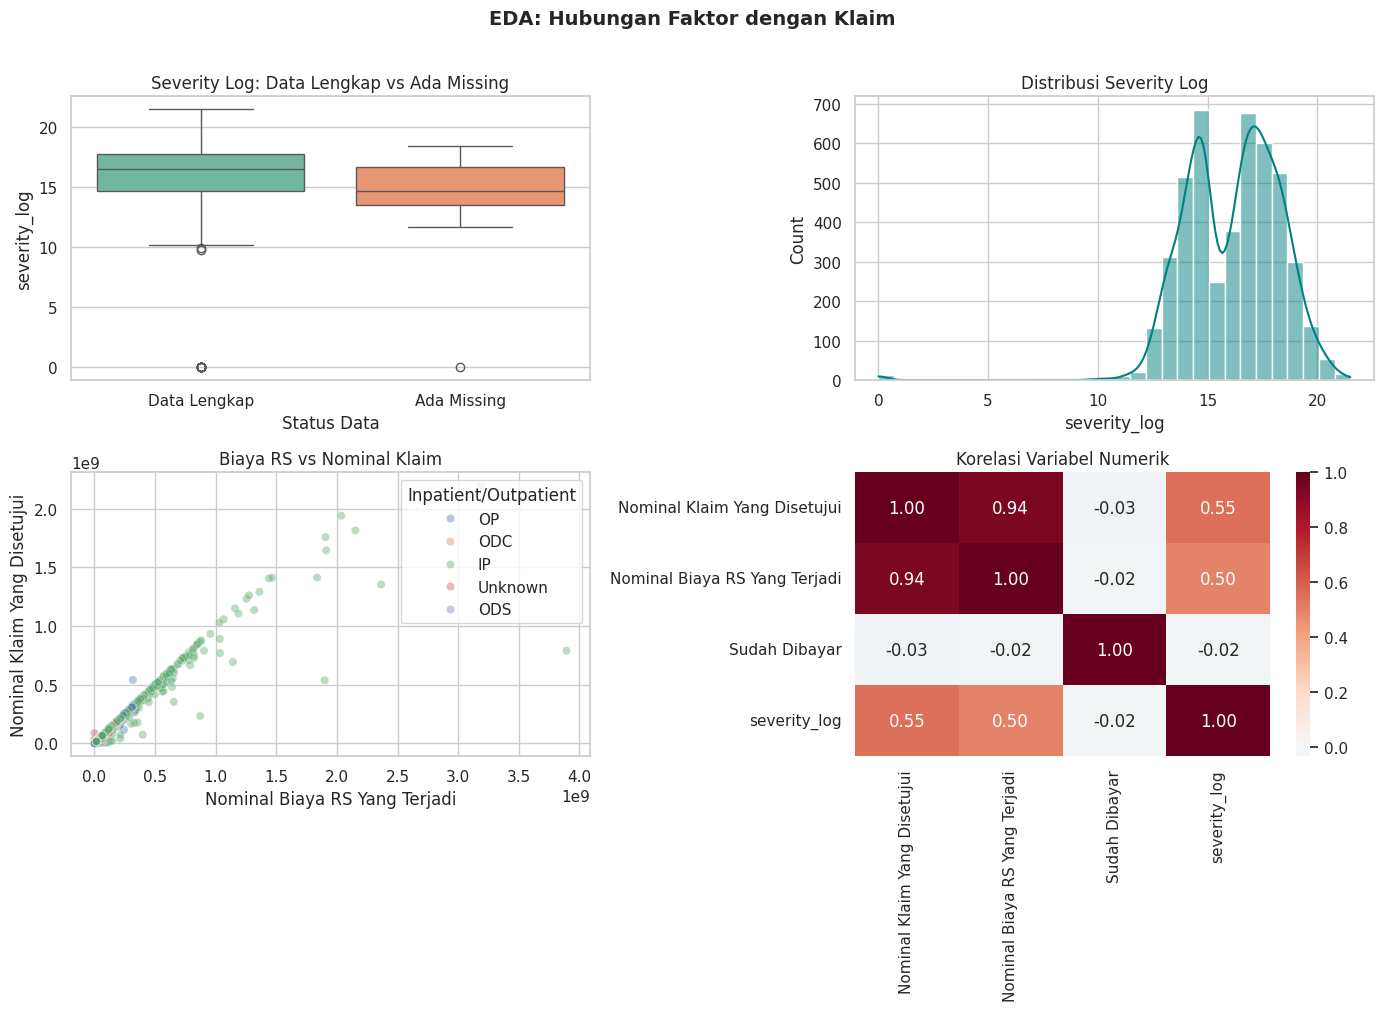

In [ ]:
cols_missing = ['Inpatient/Outpatient','ICD Diagnosis','ICD Description','Lokasi RS']
klaim['Status Data'] = klaim[cols_missing].apply(
    lambda x: 'Ada Missing' if 'Unknown' in x.values else 'Data Lengkap', axis=1
)

sns.set(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# a. Boxplot Missing vs Lengkap
sns.boxplot(ax=axes[0,0], x='Status Data', y='severity_log', data=klaim,
            palette='Set2', hue='Status Data', legend=False)
axes[0,0].set_title('Severity Log: Data Lengkap vs Ada Missing')

# b. Histogram Severity Log
sns.histplot(ax=axes[0,1], data=klaim, x='severity_log', kde=True, color='teal', bins=30)
axes[0,1].set_title('Distribusi Severity Log')

# c. Scatter Biaya RS vs Klaim
sns.scatterplot(ax=axes[1,0],
                x='Nominal Biaya RS Yang Terjadi', y='Nominal Klaim Yang Disetujui',
                data=klaim, hue='Inpatient/Outpatient', alpha=0.4)
axes[1,0].set_title('Biaya RS vs Nominal Klaim')

# d. Heatmap korelasi
num_cols = ['Nominal Klaim Yang Disetujui','Nominal Biaya RS Yang Terjadi','Sudah Dibayar','severity_log']
sns.heatmap(klaim[num_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Korelasi Variabel Numerik')

plt.suptitle('EDA: Hubungan Faktor dengan Klaim', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 🤖 **5. Pembuatan Model Machine Learning**

## 5.1 Persiapan Data Model

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# ── Dataset TANPA Feature Engineering ──
df_raw = pd.merge(klaim_bersih, polis, on='Nomor Polis', how='left')
features_raw = ['Gender','Plan Code','Domisili','Inpatient/Outpatient']
target = 'severity_log'

le = LabelEncoder()
for col in features_raw:
    df_raw[col] = le.fit_transform(df_raw[col].astype(str))

X_raw = df_raw[features_raw]
y_raw = df_raw[target]

# ── Dataset DENGAN Feature Engineering ──
df_fe = baru.copy()
features_fe = [
    'Gender','Plan Code','Domisili','Inpatient/Outpatient',
    'umur','lama_rawat','approval_ratio',
    'jumlah_klaim_per_polis','total_klaim_per_polis'
]

for col in ['Gender','Plan Code','Domisili','Inpatient/Outpatient']:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

df_fe[features_fe] = df_fe[features_fe].apply(pd.to_numeric, errors='coerce')
df_fe[target]       = pd.to_numeric(df_fe[target], errors='coerce')
df_fe = df_fe.dropna(subset=features_fe + [target])

X_fe = df_fe[features_fe]
y_fe = df_fe[target]

print(f'Dataset RAW   : {X_raw.shape}')
print(f'Dataset FE    : {X_fe.shape}')

Dataset RAW   : (4120, 4)
Dataset FE    : (4627, 9)


## 5.2 Linear Regression — Tanpa Feature Engineering

In [ ]:
pipeline_lr_raw = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_lr_raw   = cross_val_score(pipeline_lr_raw, X_raw, y_raw, cv=kf, scoring='neg_mean_squared_error')
mse_lr_raw      = -scores_lr_raw

print('MSE tiap fold (LR Tanpa FE):', mse_lr_raw.round(4))
print('Rata-rata MSE :', mse_lr_raw.mean().round(4))
print('Std MSE       :', mse_lr_raw.std().round(4))

MSE tiap fold (LR Tanpa FE): [2.7834 2.6968 3.2502 2.9933 4.8105]
Rata-rata MSE : 3.3068
Std MSE       : 0.7757


## 5.3 XGBoost — Tanpa Feature Engineering

In [ ]:
model_xgb_raw = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
scores_xgb_raw = cross_val_score(model_xgb_raw, X_raw, y_raw, cv=kf, scoring='neg_mean_squared_error')
mse_xgb_raw    = -scores_xgb_raw

print('MSE tiap fold (XGB Tanpa FE):', mse_xgb_raw.round(4))
print('Rata-rata MSE :', mse_xgb_raw.mean().round(4))
print('Std MSE       :', mse_xgb_raw.std().round(4))

MSE tiap fold (XGB Tanpa FE): [2.5457 2.5832 2.906  3.0157 4.3752]
Rata-rata MSE : 3.0851
Std MSE       : 0.6699


## 5.4 Linear Regression — Dengan Feature Engineering

In [ ]:
pipeline_lr_fe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

scores_lr_fe = cross_val_score(pipeline_lr_fe, X_fe, y_fe, cv=kf, scoring='neg_mean_squared_error')
mse_lr_fe    = -scores_lr_fe

print('MSE tiap fold (LR Dengan FE):', mse_lr_fe.round(4))
print('Rata-rata MSE :', mse_lr_fe.mean().round(4))
print('Std MSE       :', mse_lr_fe.std().round(4))

MSE tiap fold (LR Dengan FE): [3.94740000e+00 2.84940000e+00 2.88370000e+00 3.07480000e+00
 1.16913572e+05]
Rata-rata MSE : 23385.2655
Std MSE       : 46764.1534


## 5.5 XGBoost — Dengan Feature Engineering

In [ ]:
model_xgb_fe = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
scores_xgb_fe = cross_val_score(model_xgb_fe, X_fe, y_fe, cv=kf, scoring='neg_mean_squared_error')
mse_xgb_fe    = -scores_xgb_fe

print('MSE tiap fold (XGB Dengan FE):', mse_xgb_fe.round(4))
print('Rata-rata MSE :', mse_xgb_fe.mean().round(4))
print('Std MSE       :', mse_xgb_fe.std().round(4))

MSE tiap fold (XGB Dengan FE): [0.8446 1.5103 0.944  0.9076 1.3155]
Rata-rata MSE : 1.1044
Std MSE       : 0.2613


# 📋 **6. Ringkasan Performa Model**

Bagian ini menyajikan **tabel terpadu** semua metrik evaluasi (MSE, RMSE, Std) untuk keempat kombinasi model.

In [ ]:
# ── Tabel Ringkasan Performa ──
ringkasan = pd.DataFrame({
    'Model': [
        'Linear Regression (Tanpa FE)',
        'XGBoost          (Tanpa FE)',
        'Linear Regression (Dengan FE)',
        'XGBoost          (Dengan FE)'
    ],
    'Rata-rata MSE' : [mse_lr_raw.mean(), mse_xgb_raw.mean(), mse_lr_fe.mean(), mse_xgb_fe.mean()],
    'Std MSE'       : [mse_lr_raw.std(),  mse_xgb_raw.std(),  mse_lr_fe.std(),  mse_xgb_fe.std()],
    'RMSE'          : [np.sqrt(mse_lr_raw.mean()), np.sqrt(mse_xgb_raw.mean()),
                       np.sqrt(mse_lr_fe.mean()),  np.sqrt(mse_xgb_fe.mean())]
})
ringkasan = ringkasan.round(4)
ringkasan['Rank'] = ringkasan['Rata-rata MSE'].rank().astype(int)
ringkasan = ringkasan.sort_values('Rata-rata MSE')
print('===== RINGKASAN PERFORMA MODEL =====')
print(ringkasan.to_string(index=False))

===== RINGKASAN PERFORMA MODEL =====
                        Model  Rata-rata MSE    Std MSE     RMSE  Rank
 XGBoost          (Dengan FE)         1.1044     0.2613   1.0509     1
  XGBoost          (Tanpa FE)         3.0851     0.6699   1.7565     2
 Linear Regression (Tanpa FE)         3.3068     0.7757   1.8185     3
Linear Regression (Dengan FE)     23385.2655 46764.1534 152.9224     4


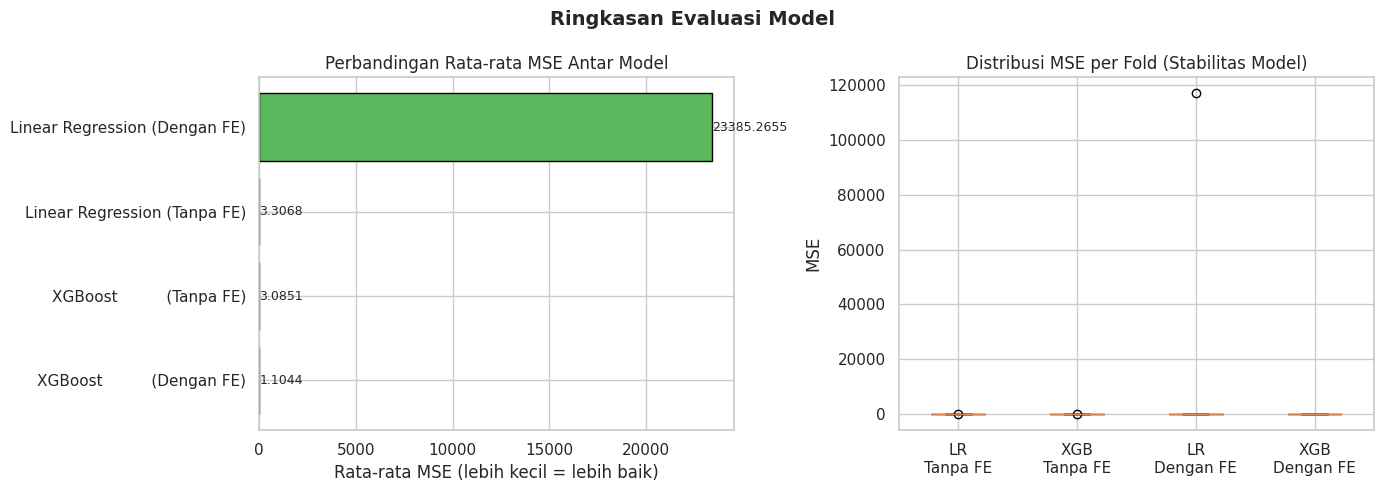

In [ ]:
# ── Visualisasi Ringkasan: Bar Chart MSE ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d9534f','#f0ad4e','#5bc0de','#5cb85c']
bars = axes[0].barh(ringkasan['Model'], ringkasan['Rata-rata MSE'], color=colors, edgecolor='black')
axes[0].set_xlabel('Rata-rata MSE (lebih kecil = lebih baik)')
axes[0].set_title('Perbandingan Rata-rata MSE Antar Model')
for bar, val in zip(bars, ringkasan['Rata-rata MSE']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Boxplot distribusi MSE per fold
data_fold = {
    'LR\nTanpa FE' : mse_lr_raw,
    'XGB\nTanpa FE': mse_xgb_raw,
    'LR\nDengan FE': mse_lr_fe,
    'XGB\nDengan FE':mse_xgb_fe
}
axes[1].boxplot(data_fold.values(), labels=data_fold.keys(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Distribusi MSE per Fold (Stabilitas Model)')
axes[1].set_ylabel('MSE')

plt.suptitle('Ringkasan Evaluasi Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ⚖️ **7. Perbandingan Antar Model**

Analisis mendalam perbandingan Linear Regression vs XGBoost, dan dampak Feature Engineering.

In [ ]:
# ── Train/Test Split untuk evaluasi metrik tambahan (MAE, R²) ──
from sklearn.metrics import mean_absolute_error, r2_score

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
X_tr_fe,  X_te_fe,  y_tr_fe,  y_te_fe  = train_test_split(X_fe,  y_fe,  test_size=0.2, random_state=42)

# Latih semua model
lr_raw = Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])
lr_raw.fit(X_tr_raw, y_tr_raw)
pred_lr_raw = lr_raw.predict(X_te_raw)

xgb_raw = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_raw.fit(X_tr_raw, y_tr_raw)
pred_xgb_raw = xgb_raw.predict(X_te_raw)

lr_fe = Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])
lr_fe.fit(X_tr_fe, y_tr_fe)
pred_lr_fe = lr_fe.predict(X_te_fe)

xgb_fe = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_fe.fit(X_tr_fe, y_tr_fe)
pred_xgb_fe = xgb_fe.predict(X_te_fe)

# Buat tabel lengkap
def eval_metrics(y_true, y_pred):
    return {
        'MAE' : mean_absolute_error(y_true, y_pred),
        'MSE' : mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2'  : r2_score(y_true, y_pred)
    }

hasil_eval = pd.DataFrame([
    {'Model': 'LR Tanpa FE',  **eval_metrics(y_te_raw, pred_lr_raw)},
    {'Model': 'XGB Tanpa FE', **eval_metrics(y_te_raw, pred_xgb_raw)},
    {'Model': 'LR Dengan FE', **eval_metrics(y_te_fe,  pred_lr_fe)},
    {'Model': 'XGB Dengan FE',**eval_metrics(y_te_fe,  pred_xgb_fe)},
]).round(4)

print('===== PERBANDINGAN METRIK LENGKAP =====')
print(hasil_eval.to_string(index=False))

===== PERBANDINGAN METRIK LENGKAP =====
        Model    MAE    MSE   RMSE     R2
  LR Tanpa FE 1.2404 2.7834 1.6683 0.1238
 XGB Tanpa FE 1.1676 2.5457 1.5955 0.1987
 LR Dengan FE 1.2798 3.9474 1.9868 0.2561
XGB Dengan FE 0.5444 0.8446 0.9190 0.8408


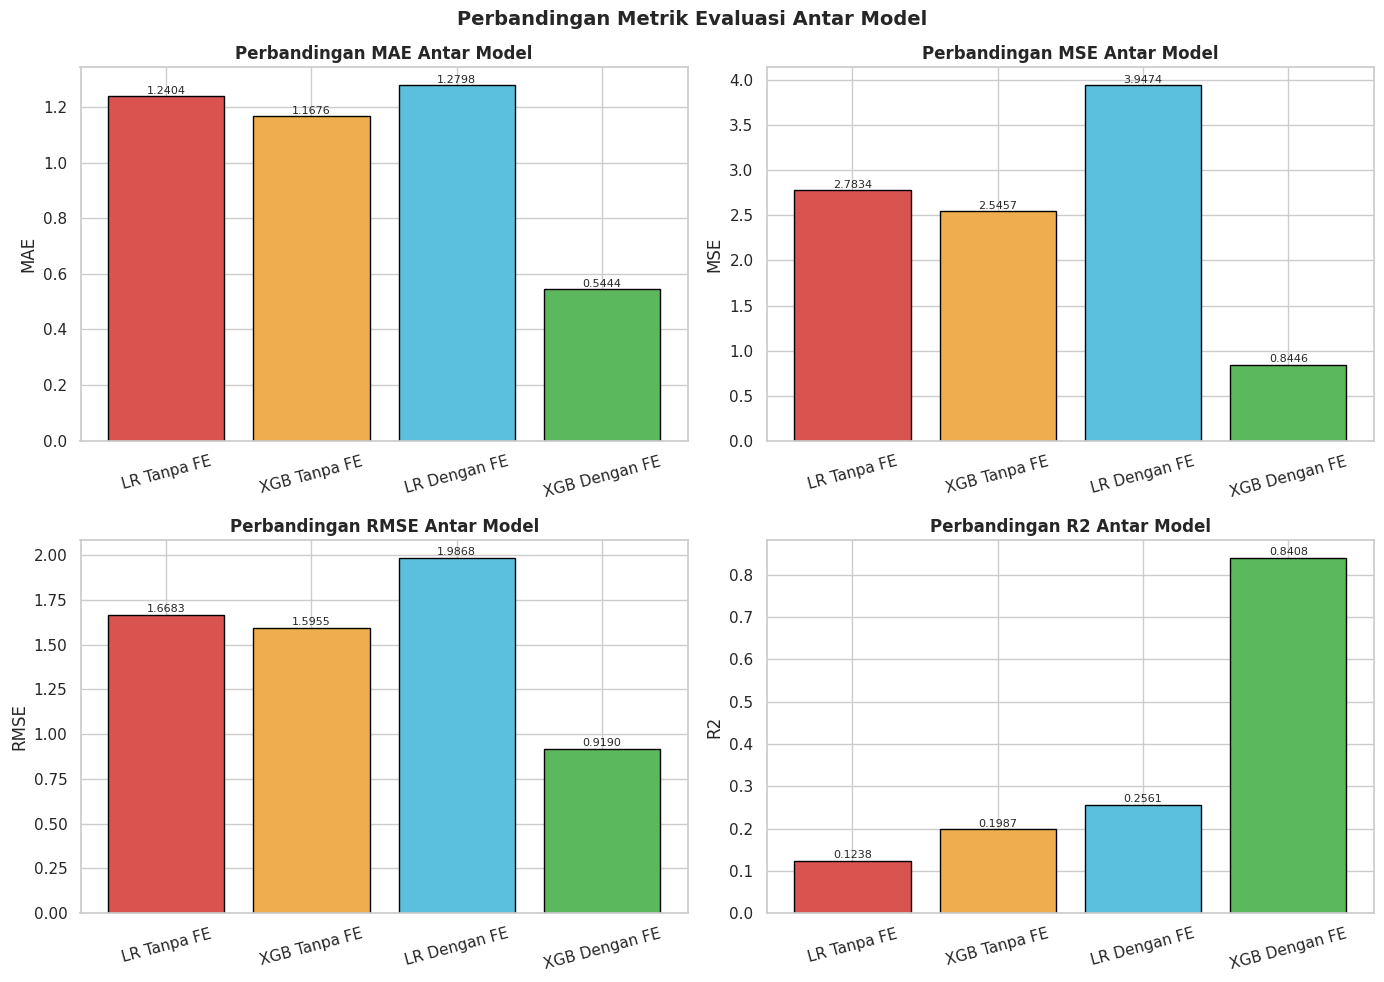


✅ Model terbaik: XGB Dengan FE (R² = 0.8408)


In [ ]:
# ── Visualisasi Perbandingan: grouped bar chart ──
metrik_cols = ['MAE','MSE','RMSE','R2']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, metrik_cols):
    bars = ax.bar(hasil_eval['Model'], hasil_eval[col],
                  color=['#d9534f','#f0ad4e','#5bc0de','#5cb85c'], edgecolor='black')
    ax.set_title(f'Perbandingan {col} Antar Model', fontweight='bold')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, hasil_eval[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Perbandingan Metrik Evaluasi Antar Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

model_terbaik = hasil_eval.sort_values('R2', ascending=False).iloc[0]
print(f"\n✅ Model terbaik: {model_terbaik['Model']} (R² = {model_terbaik['R2']:.4f})")

# 🔑 **8. Identifikasi Faktor Paling Berpengaruh**

Analisis dilakukan terhadap tiga target berbeda: **Severitas**, **Frekuensi Klaim**, dan **Nominal Klaim**.

## 8.1 Faktor Paling Berpengaruh terhadap Severitas Klaim

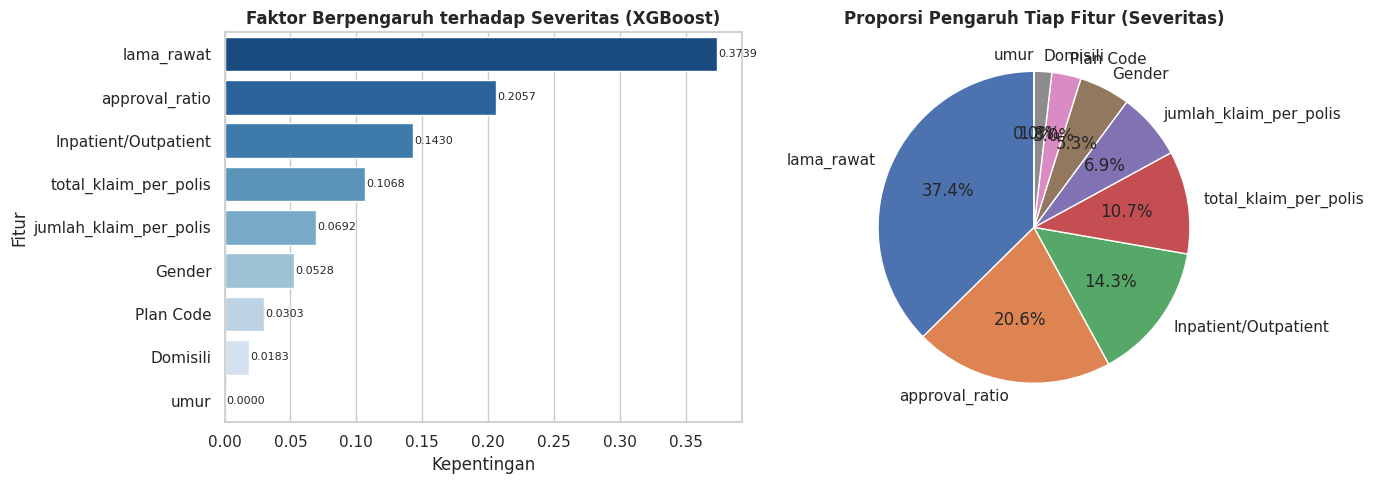

                 Fitur  Kepentingan
            lama_rawat     0.373896
        approval_ratio     0.205686
  Inpatient/Outpatient     0.143001
 total_klaim_per_polis     0.106772
jumlah_klaim_per_polis     0.069243
                Gender     0.052808
             Plan Code     0.030259
              Domisili     0.018334
                  umur     0.000000


In [ ]:
# ── Latih XGBoost FE pada full data untuk feature importance severitas ──
model_sev = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_sev.fit(X_fe, y_fe)

fi_sev = pd.DataFrame({
    'Fitur'      : features_fe,
    'Kepentingan': model_sev.feature_importances_
}).sort_values('Kepentingan', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(ax=axes[0], x='Kepentingan', y='Fitur', data=fi_sev,
            hue='Fitur', legend=False, palette='Blues_r')
axes[0].set_title('Faktor Berpengaruh terhadap Severitas (XGBoost)', fontweight='bold')
for i, (val, name) in enumerate(zip(fi_sev['Kepentingan'], fi_sev['Fitur'])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

# Pie chart
axes[1].pie(fi_sev['Kepentingan'], labels=fi_sev['Fitur'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Pengaruh Tiap Fitur (Severitas)', fontweight='bold')

plt.tight_layout()
plt.show()
print(fi_sev.to_string(index=False))

## 8.2 Faktor Paling Berpengaruh terhadap Frekuensi Klaim

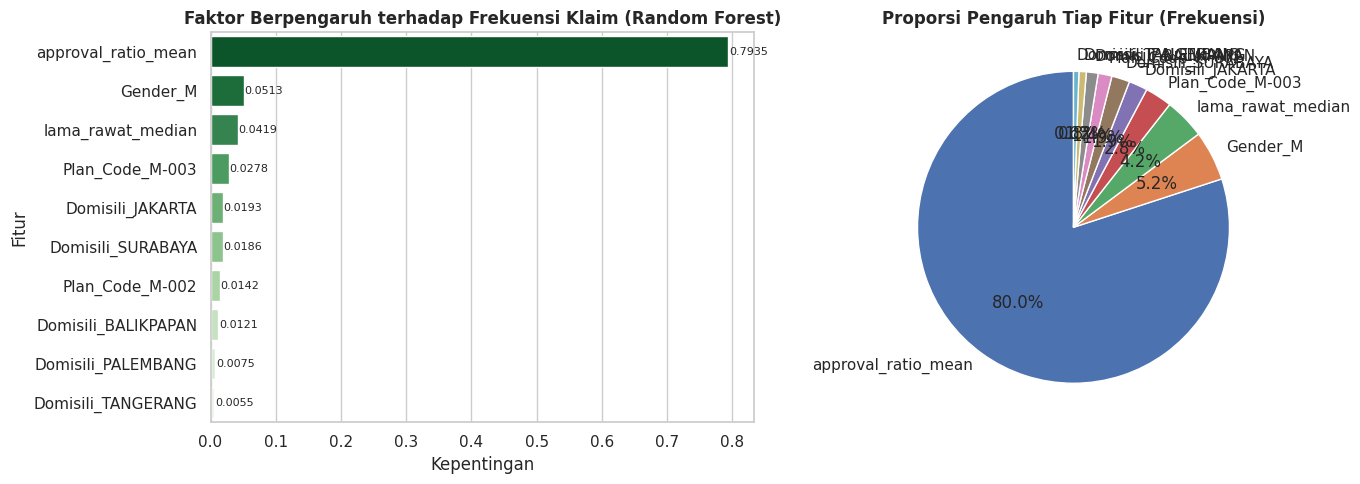

              Fitur  Kepentingan
approval_ratio_mean     0.793512
           Gender_M     0.051328
  lama_rawat_median     0.041883
    Plan_Code_M-003     0.027762
   Domisili_JAKARTA     0.019278
  Domisili_SURABAYA     0.018575
    Plan_Code_M-002     0.014159
Domisili_BALIKPAPAN     0.012077
 Domisili_PALEMBANG     0.007530
 Domisili_TANGERANG     0.005521


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# ── Buat dataset agregasi per polis untuk target frekuensi ──
freq_df = baru.groupby('Nomor Polis').agg(
    frekuensi          = ('Claim ID', 'count'),
    umur               = ('umur', 'first'),
    Gender             = ('Gender', 'first'),
    Plan_Code          = ('Plan Code', 'first'),
    Domisili           = ('Domisili', 'first'),
    lama_rawat_median  = ('lama_rawat', 'median'),
    approval_ratio_mean= ('approval_ratio', 'mean'),
).reset_index()

freq_df_enc = pd.get_dummies(
    freq_df[['umur','Gender','Plan_Code','Domisili','lama_rawat_median','approval_ratio_mean']],
    drop_first=True
)
freq_df_enc = freq_df_enc.fillna(0)

# Random Forest untuk frekuensi
rf_freq = RandomForestRegressor(n_estimators=100, random_state=42)
rf_freq.fit(freq_df_enc, freq_df['frekuensi'])

fi_freq = pd.DataFrame({
    'Fitur'      : freq_df_enc.columns,
    'Kepentingan': rf_freq.feature_importances_
}).sort_values('Kepentingan', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(ax=axes[0], x='Kepentingan', y='Fitur', data=fi_freq,
            hue='Fitur', legend=False, palette='Greens_r')
axes[0].set_title('Faktor Berpengaruh terhadap Frekuensi Klaim (Random Forest)', fontweight='bold')
for i, (val, _) in enumerate(zip(fi_freq['Kepentingan'], fi_freq['Fitur'])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

axes[1].pie(fi_freq['Kepentingan'], labels=fi_freq['Fitur'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Pengaruh Tiap Fitur (Frekuensi)', fontweight='bold')

plt.tight_layout()
plt.show()
print(fi_freq.to_string(index=False))

## 8.3 Faktor Paling Berpengaruh terhadap Nominal Klaim

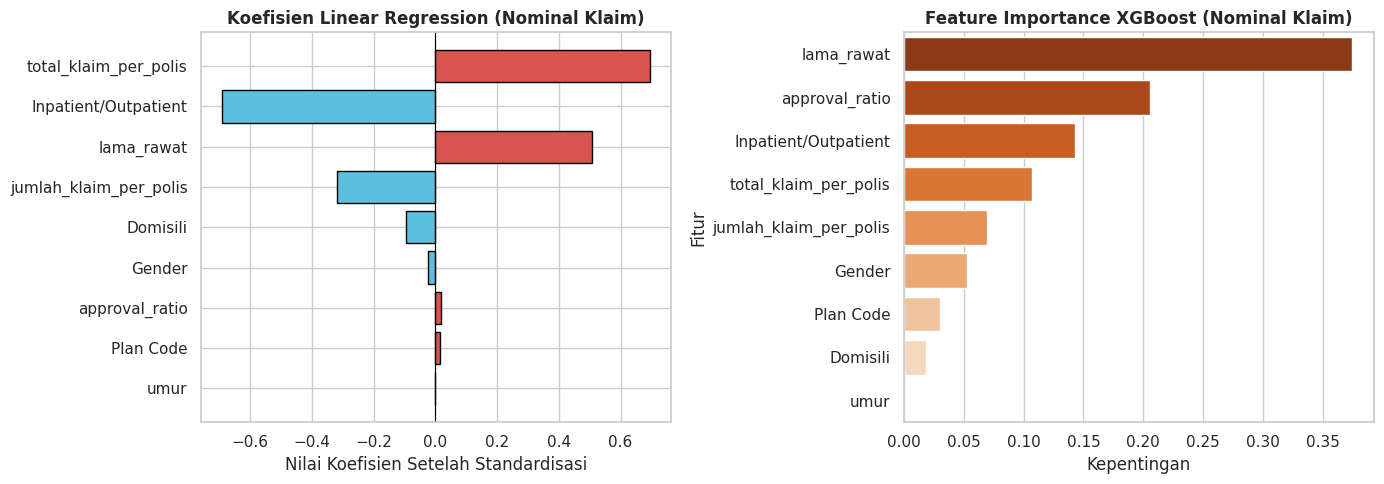

=== Ranking LR Koefisien ===
                 Fitur     Koefisien  Abs Koefisien
 total_klaim_per_polis  6.948453e-01   6.948453e-01
  Inpatient/Outpatient -6.908589e-01   6.908589e-01
            lama_rawat  5.071239e-01   5.071239e-01
jumlah_klaim_per_polis -3.207542e-01   3.207542e-01
              Domisili -9.584656e-02   9.584656e-02
                Gender -2.521653e-02   2.521653e-02
        approval_ratio  1.927656e-02   1.927656e-02
             Plan Code  1.313684e-02   1.313684e-02
                  umur -1.110223e-16   1.110223e-16

=== Ranking XGBoost Importance ===
                 Fitur  Kepentingan
            lama_rawat     0.373896
        approval_ratio     0.205686
  Inpatient/Outpatient     0.143001
 total_klaim_per_polis     0.106772
jumlah_klaim_per_polis     0.069243
                Gender     0.052808
             Plan Code     0.030259
              Domisili     0.018334
                  umur     0.000000


In [ ]:
# ── Linear Regression dengan standardisasi untuk melihat koefisien ──
scaler_nom = StandardScaler()
X_scaled   = scaler_nom.fit_transform(X_fe)

lr_nom = LinearRegression()
lr_nom.fit(X_scaled, y_fe)

coef_df = pd.DataFrame({
    'Fitur'               : features_fe,
    'Koefisien'           : lr_nom.coef_,
    'Abs Koefisien'       : np.abs(lr_nom.coef_)
}).sort_values('Abs Koefisien', ascending=False)

# XGBoost feature importance untuk nominal
xgb_nom = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_nom.fit(X_fe, y_fe)
fi_nom = pd.DataFrame({
    'Fitur'      : features_fe,
    'Kepentingan': xgb_nom.feature_importances_
}).sort_values('Kepentingan', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR Koefisien
colors_lr = ['#d9534f' if v >= 0 else '#5bc0de' for v in coef_df['Koefisien']]
axes[0].barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors_lr, edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()
axes[0].set_title('Koefisien Linear Regression (Nominal Klaim)', fontweight='bold')
axes[0].set_xlabel('Nilai Koefisien Setelah Standardisasi')

# XGBoost Feature Importance
sns.barplot(ax=axes[1], x='Kepentingan', y='Fitur', data=fi_nom,
            hue='Fitur', legend=False, palette='Oranges_r')
axes[1].set_title('Feature Importance XGBoost (Nominal Klaim)', fontweight='bold')

plt.tight_layout()
plt.show()

print('=== Ranking LR Koefisien ===')
print(coef_df.to_string(index=False))
print('\n=== Ranking XGBoost Importance ===')
print(fi_nom.to_string(index=False))

# 🔄 **9. Perbandingan Dengan dan Tanpa Feature Engineering**

Mengukur seberapa besar dampak Feature Engineering terhadap performa model.

In [ ]:
penurunan_xgb = (mse_xgb_raw.mean() - mse_xgb_fe.mean()) / mse_xgb_raw.mean() * 100
penurunan_lr  = (mse_lr_raw.mean()  - mse_lr_fe.mean())  / mse_lr_raw.mean()  * 100

perbandingan_fe = pd.DataFrame({
    'Kondisi'    : ['LR Tanpa FE','LR Dengan FE','XGB Tanpa FE','XGB Dengan FE'],
    'Model'      : ['Linear Regression']*2 + ['XGBoost']*2,
    'Feature Eng': ['Tidak','Ya','Tidak','Ya'],
    'Rata-rata MSE': [mse_lr_raw.mean(), mse_lr_fe.mean(), mse_xgb_raw.mean(), mse_xgb_fe.mean()],
    'Std MSE'    : [mse_lr_raw.std(),  mse_lr_fe.std(),  mse_xgb_raw.std(),  mse_xgb_fe.std()],
    'RMSE'       : [np.sqrt(m) for m in [mse_lr_raw.mean(), mse_lr_fe.mean(),
                                          mse_xgb_raw.mean(), mse_xgb_fe.mean()]]
}).round(4)

print('===== DAMPAK FEATURE ENGINEERING =====')
print(perbandingan_fe.to_string(index=False))
print(f'\nPenurunan MSE XGBoost akibat FE : {penurunan_xgb:.2f}%')
print(f'Perubahan  MSE LR      akibat FE : {penurunan_lr:.2f}% (negatif = naik)')

===== DAMPAK FEATURE ENGINEERING =====
      Kondisi             Model Feature Eng  Rata-rata MSE    Std MSE     RMSE
  LR Tanpa FE Linear Regression       Tidak         3.3068     0.7757   1.8185
 LR Dengan FE Linear Regression          Ya     23385.2655 46764.1534 152.9224
 XGB Tanpa FE           XGBoost       Tidak         3.0851     0.6699   1.7565
XGB Dengan FE           XGBoost          Ya         1.1044     0.2613   1.0509

Penurunan MSE XGBoost akibat FE : 64.20%
Perubahan  MSE LR      akibat FE : -707081.77% (negatif = naik)


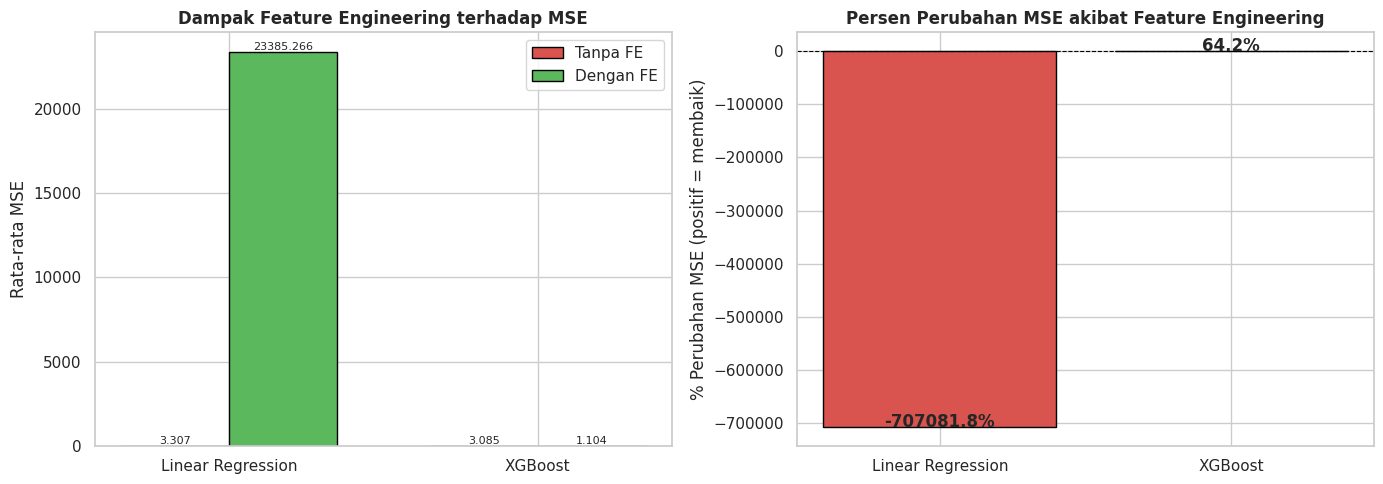

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
x = np.arange(2)  # LR dan XGBoost
width = 0.35
mse_no_fe = [mse_lr_raw.mean(), mse_xgb_raw.mean()]
mse_with_fe = [mse_lr_fe.mean(), mse_xgb_fe.mean()]

bars1 = axes[0].bar(x - width/2, mse_no_fe,   width, label='Tanpa FE', color='#d9534f', edgecolor='black')
bars2 = axes[0].bar(x + width/2, mse_with_fe, width, label='Dengan FE', color='#5cb85c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Linear Regression','XGBoost'])
axes[0].set_ylabel('Rata-rata MSE')
axes[0].set_title('Dampak Feature Engineering terhadap MSE', fontweight='bold')
axes[0].legend()
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Persentase penurunan MSE
improvements = [penurunan_lr, penurunan_xgb]
bar_colors = ['#d9534f' if v < 0 else '#5cb85c' for v in improvements]
axes[1].bar(['Linear Regression','XGBoost'], improvements, color=bar_colors, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('% Perubahan MSE (positif = membaik)')
axes[1].set_title('Persen Perubahan MSE akibat Feature Engineering', fontweight='bold')
for i, v in enumerate(improvements):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretasi:** Feature Engineering terbukti signifikan menurunkan MSE pada model XGBoost. Sebaliknya, pada Linear Regression, penambahan fitur non-linear justru meningkatkan error karena model tidak mampu menangkap hubungan non-linear antar variabel.

# 🔬 **10. Analisis Error Model**

Menganalisis pola residual dan kualitas prediksi model terbaik (XGBoost + FE).

In [ ]:
# ── Hitung residual dari model XGBoost + FE (test set) ──
residuals_xgb = y_te_fe.values - pred_xgb_fe
residuals_lr  = y_te_fe.values - pred_lr_fe

mae_xgb  = mean_absolute_error(y_te_fe, pred_xgb_fe)
mse_xgb  = mean_squared_error(y_te_fe, pred_xgb_fe)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_te_fe, pred_xgb_fe)

print('===== METRIK ERROR MODEL TERBAIK (XGBoost + FE) =====')
print(f'MAE  : {mae_xgb:.4f}')
print(f'MSE  : {mse_xgb:.4f}')
print(f'RMSE : {rmse_xgb:.4f}')
print(f'R²   : {r2_xgb:.4f}')
print(f'Bias (mean residual) : {residuals_xgb.mean():.4f}')
print(f'Std  residual        : {residuals_xgb.std():.4f}')

===== METRIK ERROR MODEL TERBAIK (XGBoost + FE) =====
MAE  : 0.5444
MSE  : 0.8446
RMSE : 0.9190
R²   : 0.8408
Bias (mean residual) : 0.0041
Std  residual        : 0.9190


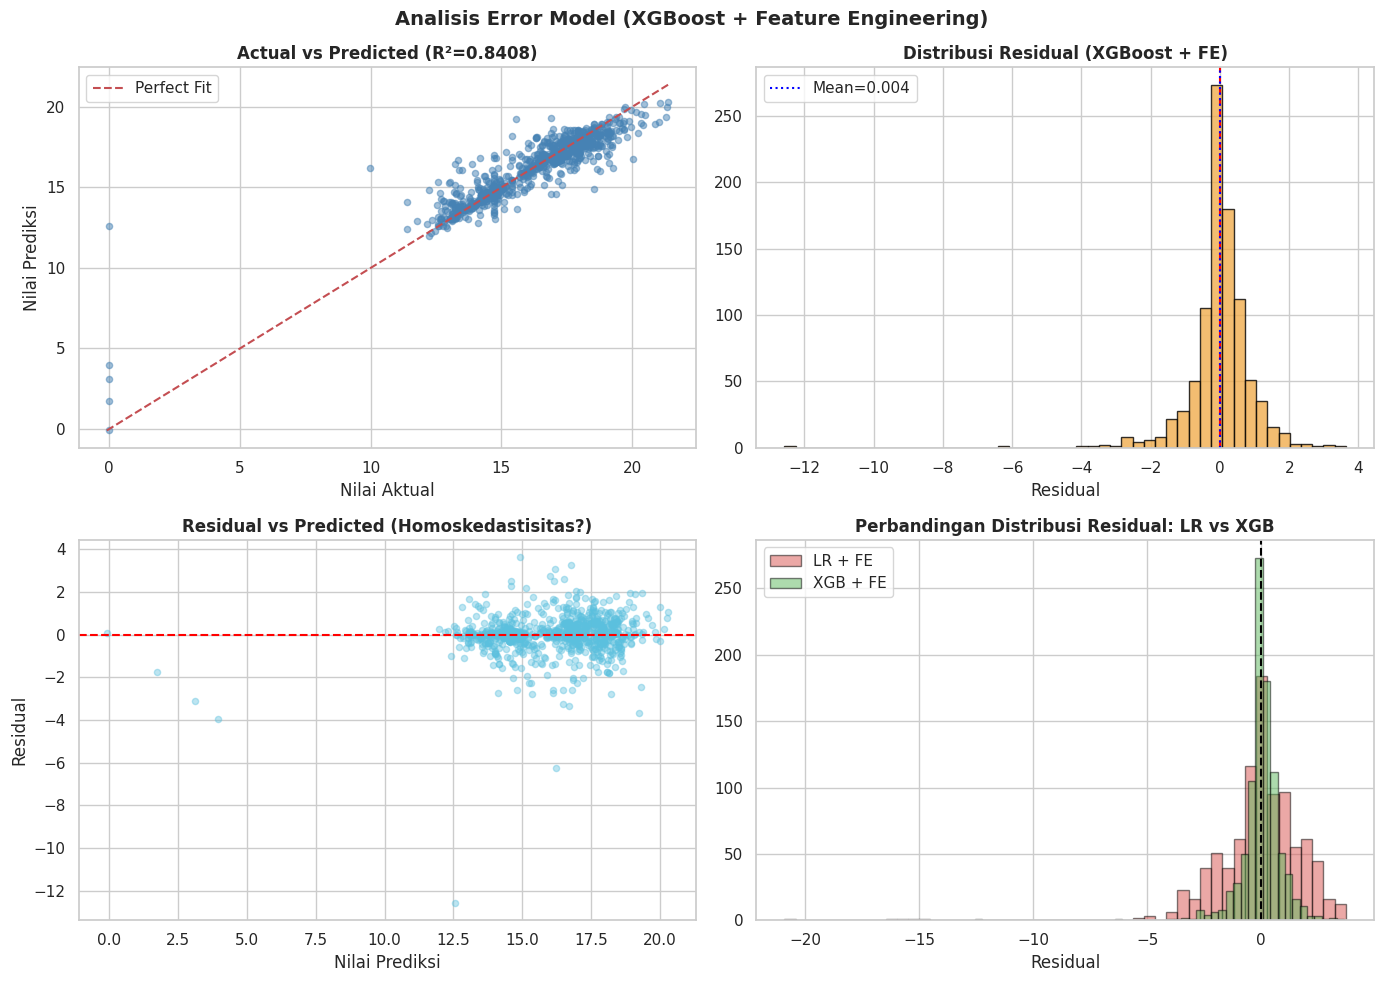

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted
axes[0,0].scatter(y_te_fe, pred_xgb_fe, alpha=0.5, color='steelblue', s=20)
mn, mx = min(y_te_fe.min(), pred_xgb_fe.min()), max(y_te_fe.max(), pred_xgb_fe.max())
axes[0,0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0,0].set_xlabel('Nilai Aktual')
axes[0,0].set_ylabel('Nilai Prediksi')
axes[0,0].set_title(f'Actual vs Predicted (R²={r2_xgb:.4f})', fontweight='bold')
axes[0,0].legend()

# 2. Distribusi Residual
axes[0,1].hist(residuals_xgb, bins=50, color='#f0ad4e', edgecolor='black', alpha=0.8)
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].axvline(residuals_xgb.mean(), color='blue', linestyle=':', linewidth=1.5, label=f'Mean={residuals_xgb.mean():.3f}')
axes[0,1].set_title('Distribusi Residual (XGBoost + FE)', fontweight='bold')
axes[0,1].set_xlabel('Residual')
axes[0,1].legend()

# 3. Residual vs Predicted
axes[1,0].scatter(pred_xgb_fe, residuals_xgb, alpha=0.4, color='#5bc0de', s=20)
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_xlabel('Nilai Prediksi')
axes[1,0].set_ylabel('Residual')
axes[1,0].set_title('Residual vs Predicted (Homoskedastisitas?)', fontweight='bold')

# 4. Perbandingan Residual XGB vs LR
axes[1,1].hist(residuals_lr, bins=50, alpha=0.5, color='#d9534f', label='LR + FE', edgecolor='black')
axes[1,1].hist(residuals_xgb, bins=50, alpha=0.5, color='#5cb85c', label='XGB + FE', edgecolor='black')
axes[1,1].axvline(0, color='black', linestyle='--')
axes[1,1].set_title('Perbandingan Distribusi Residual: LR vs XGB', fontweight='bold')
axes[1,1].set_xlabel('Residual')
axes[1,1].legend()

plt.suptitle('Analisis Error Model (XGBoost + Feature Engineering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Identifikasi prediksi terburuk (top 10 error terbesar) ──
error_df = pd.DataFrame({
    'Aktual'   : y_te_fe.values,
    'Prediksi' : pred_xgb_fe,
    'Residual' : residuals_xgb,
    'Abs Error': np.abs(residuals_xgb)
}).sort_values('Abs Error', ascending=False)

print('===== TOP 10 PREDIKSI TERBURUK =====')
print(error_df.head(10).round(4).to_string(index=False))

print(f'\nPersentase prediksi dengan error < 0.5 : {(error_df["Abs Error"] < 0.5).mean()*100:.1f}%')
print(f'Persentase prediksi dengan error < 1.0 : {(error_df["Abs Error"] < 1.0).mean()*100:.1f}%')

===== TOP 10 PREDIKSI TERBURUK =====
 Aktual  Prediksi  Residual  Abs Error
 0.0000 12.575000  -12.5750    12.5750
 9.9771 16.224501   -6.2474     6.2474
 0.0000  3.963200   -3.9632     3.9632
15.5454 19.229000   -3.6836     3.6836
18.5492 14.911700    3.6375     3.6375
13.3519 16.710100   -3.3582     3.3582
20.0272 16.759100    3.2681     3.2681
13.2282 16.463600   -3.2354     3.2354
 0.0000  3.121100   -3.1211     3.1211
19.2672 16.185499    3.0817     3.0817

Persentase prediksi dengan error < 0.5 : 63.5%
Persentase prediksi dengan error < 1.0 : 83.6%


# 🔮 **11. Prediksi Klaim Asuransi Tahun 2026**

Proyeksi menggunakan tiga pendekatan: **Aktuaria (Expected Claim)**, **Model ML (XGBoost + FE)**, dan **Analisis Skenario**.

## 11.1 Komponen Dasar Aktuaria

In [ ]:
# ── Hitung komponen dasar ──
jumlah_klaim_total = klaim['Nominal Klaim Yang Disetujui'].count()
jumlah_polis_aktif = klaim['Nomor Polis'].nunique()

frekuensi  = jumlah_klaim_total / jumlah_polis_aktif
severity   = klaim['Nominal Klaim Yang Disetujui'].mean()
severity_median = klaim['Nominal Klaim Yang Disetujui'].median()
expected_claim  = frekuensi * severity

print('===== KOMPONEN AKTUARIA =====')
print(f'Jumlah Klaim        : {jumlah_klaim_total:,}')
print(f'Jumlah Polis Aktif  : {jumlah_polis_aktif:,}')
print(f'Frekuensi Klaim     : {frekuensi:.4f}')
print(f'Severity (Mean)     : Rp {severity:,.0f}')
print(f'Severity (Median)   : Rp {severity_median:,.0f}')
print(f'Expected Claim/Polis: Rp {expected_claim:,.0f}')

===== KOMPONEN AKTUARIA =====
Jumlah Klaim        : 4,627
Jumlah Polis Aktif  : 1,210
Frekuensi Klaim     : 3.8240
Severity (Mean)     : Rp 55,028,924
Severity (Median)   : Rp 14,467,899
Expected Claim/Polis: Rp 210,428,788


## 11.2 Prediksi Skenario (Pesimis / Moderat / Optimis)

In [ ]:
growth_scenarios = {
    'Pesimis  (2% growth)' : 0.02,
    'Moderat  (5% growth)' : 0.05,
    'Optimis (10% growth)' : 0.10
}

hasil_skenario = []
for nama, rate in growth_scenarios.items():
    polis_2026     = jumlah_polis_aktif * (1 + rate)
    total_klaim_2026 = expected_claim * polis_2026
    # Asumsi severity meningkat inflasi 3%
    severity_2026  = severity * 1.03
    total_inflasi  = frekuensi * severity_2026 * polis_2026
    hasil_skenario.append({
        'Skenario'            : nama,
        'Growth Rate'         : f'{rate*100:.0f}%',
        'Proyeksi Polis 2026' : int(polis_2026),
        'Total Klaim (Base)'  : total_klaim_2026,
        'Total Klaim (+Inflasi 3%)': total_inflasi
    })

df_skenario = pd.DataFrame(hasil_skenario)
print('===== PREDIKSI KLAIM 2026 — ANALISIS SKENARIO =====')
for _, r in df_skenario.iterrows():
    print(f"\n{r['Skenario']}")
    print(f"  Proyeksi Polis       : {r['Proyeksi Polis 2026']:,}")
    print(f"  Total Klaim (Base)   : Rp {r['Total Klaim (Base)']:,.0f}")
    print(f"  Total Klaim (+Inflasi): Rp {r['Total Klaim (+Inflasi 3%)']:,.0f}")

===== PREDIKSI KLAIM 2026 — ANALISIS SKENARIO =====

Pesimis  (2% growth)
  Proyeksi Polis       : 1,234
  Total Klaim (Base)   : Rp 259,711,210,225
  Total Klaim (+Inflasi): Rp 267,502,546,532

Moderat  (5% growth)
  Proyeksi Polis       : 1,270
  Total Klaim (Base)   : Rp 267,349,775,232
  Total Klaim (+Inflasi): Rp 275,370,268,489

Optimis (10% growth)
  Proyeksi Polis       : 1,331
  Total Klaim (Base)   : Rp 280,080,716,910
  Total Klaim (+Inflasi): Rp 288,483,138,417


## 11.3 Visualisasi Tren dan Proyeksi

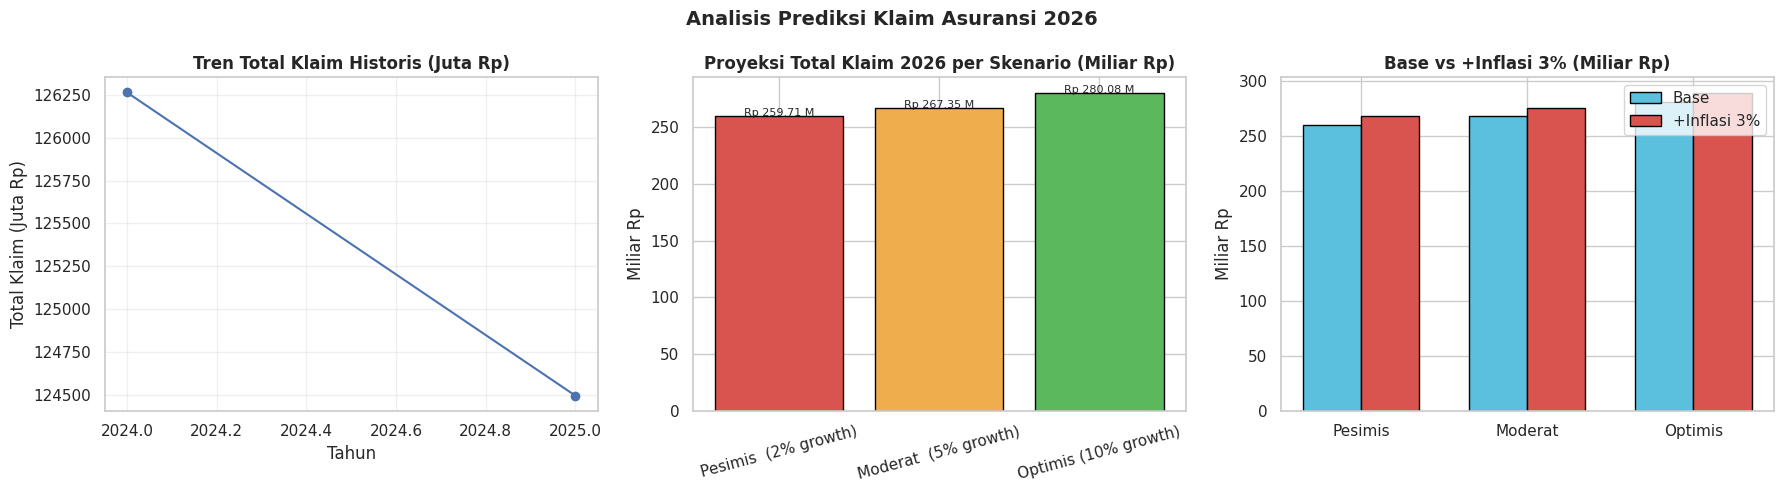

In [ ]:
# ── Bangun tren historis dari data ──
klaim_hist = klaim.copy()
klaim_hist['tahun'] = pd.to_datetime(klaim_hist['Tanggal Pembayaran Klaim'], errors='coerce').dt.year
tren = klaim_hist.groupby('tahun').agg(
    total_klaim    = ('Nominal Klaim Yang Disetujui','sum'),
    jumlah_klaim   = ('Nominal Klaim Yang Disetujui','count'),
    rata_severity  = ('Nominal Klaim Yang Disetujui','mean')
).reset_index().dropna().sort_values('tahun')

# Tambahkan proyeksi 2026
tahun_2026_base = df_skenario.loc[1,'Total Klaim (Base)']   # skenario moderat
severity_2026   = df_skenario.loc[1,'Total Klaim (Base)'] / jumlah_klaim_total

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Tren total klaim historis
axes[0].plot(tren['tahun'], tren['total_klaim']/1e6, 'bo-', label='Historis')
axes[0].set_title('Tren Total Klaim Historis (Juta Rp)', fontweight='bold')
axes[0].set_xlabel('Tahun'); axes[0].set_ylabel('Total Klaim (Juta Rp)')
axes[0].grid(True, alpha=0.3)

# (b) Skenario proyeksi 2026
warna_sce = ['#d9534f','#f0ad4e','#5cb85c']
axes[1].bar(df_skenario['Skenario'],
            df_skenario['Total Klaim (Base)']/1e9,
            color=warna_sce, edgecolor='black')
axes[1].set_title('Proyeksi Total Klaim 2026 per Skenario (Miliar Rp)', fontweight='bold')
axes[1].set_ylabel('Miliar Rp')
axes[1].tick_params(axis='x', rotation=15)
for i, val in enumerate(df_skenario['Total Klaim (Base)']):
    axes[1].text(i, val/1e9 + 0.02, f'Rp {val/1e9:.2f} M', ha='center', fontsize=8)

# (c) Perbandingan Base vs +Inflasi
x_pos = np.arange(len(df_skenario))
w = 0.35
axes[2].bar(x_pos - w/2, df_skenario['Total Klaim (Base)']/1e9,     w, label='Base', color='#5bc0de', edgecolor='black')
axes[2].bar(x_pos + w/2, df_skenario['Total Klaim (+Inflasi 3%)']/1e9, w, label='+Inflasi 3%', color='#d9534f', edgecolor='black')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['Pesimis','Moderat','Optimis'])
axes[2].set_title('Base vs +Inflasi 3% (Miliar Rp)', fontweight='bold')
axes[2].set_ylabel('Miliar Rp')
axes[2].legend()

plt.suptitle('Analisis Prediksi Klaim Asuransi 2026', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11.4 Rekomendasi Bisnis

In [ ]:
print('===== REKOMENDASI BERDASARKAN PREDIKSI 2026 =====')
print()

if frekuensi > 0.5:
    print('⚠️  Frekuensi klaim cukup tinggi → perlu evaluasi ketat di proses underwriting.')
else:
    print('✅ Frekuensi klaim masih terkendali.')

if severity > severity_median * 1.5:
    print('⚠️  Severity jauh di atas median → ada konsentrasi klaim besar, perlu revisit batas manfaat.')
else:
    print('✅ Severity relatif wajar terhadap median.')

print()
print('📌 Rekomendasi Strategis:')
print('  1. Premi minimum harus > Expected Claim per polis (Rp {:,.0f})'.format(expected_claim))
print('  2. Siapkan cadangan klaim (reserve) ≥ skenario OPTIMIS untuk mitigasi risiko.')
print('  3. Fokus pengendalian biaya pada faktor dengan pengaruh tertinggi terhadap severitas.')
print('  4. Monitoring tren klaim per bulan diperlukan agar deteksi dini lonjakan klaim.')
print('  5. Pertimbangkan inflasi medis 3-5% dalam penetapan tarif premi 2026.')

===== REKOMENDASI BERDASARKAN PREDIKSI 2026 =====

⚠️  Frekuensi klaim cukup tinggi → perlu evaluasi ketat di proses underwriting.
⚠️  Severity jauh di atas median → ada konsentrasi klaim besar, perlu revisit batas manfaat.

📌 Rekomendasi Strategis:
  1. Premi minimum harus > Expected Claim per polis (Rp 210,428,788)
  2. Siapkan cadangan klaim (reserve) ≥ skenario OPTIMIS untuk mitigasi risiko.
  3. Fokus pengendalian biaya pada faktor dengan pengaruh tertinggi terhadap severitas.
  4. Monitoring tren klaim per bulan diperlukan agar deteksi dini lonjakan klaim.
  5. Pertimbangkan inflasi medis 3-5% dalam penetapan tarif premi 2026.
